In [3]:
import numpy as np
import random as rd
from itertools import product as iproduct
from collections import Counter

In [4]:
MARKER_PENALTY_H2 = 0.15
N_SIMULATIONS = 5000   

COLUMNS = range(2, 13)

Ns = {
    2: 3, 3: 5, 4: 7, 5: 9, 6: 11,
    7: 13,
    8: 11, 9: 9, 10: 7, 11: 5, 12: 3
}

In [5]:
def _compute_prob_col(target):
    count = 0
    for roll in iproduct(range(1, 7), repeat=4):
        d1, d2, d3, d4 = roll
        sums = {d1+d2, d3+d4, d1+d3, d2+d4, d1+d4, d2+d3}
        if target in sums:
            count += 1
    return count / 1296

PROB_COL = {c: _compute_prob_col(c) for c in COLUMNS}
ALL_ROLLS = list(iproduct(range(1, 7), repeat=4))

In [6]:
def get_pairings(roll):
    d1, d2, d3, d4 = roll
    pairings = [
        tuple(sorted((d1+d2, d3+d4))),
        tuple(sorted((d1+d3, d2+d4))),
        tuple(sorted((d1+d4, d2+d3))),
    ]
    seen = set()
    unique = []
    for p in pairings:
        if p not in seen:
            seen.add(p)
            unique.append(p)
    return unique


def action_is_legal(action, progress, temp_progress):
    new_cols = set()
    for s in action:
        if progress[s] + temp_progress.get(s, 0) >= Ns[s]:
            return False
        if s not in temp_progress:
            new_cols.add(s)
    return len(temp_progress) + len(new_cols) <= 3


def apply_action(action, progress, temp_progress):
    new_temp = temp_progress.copy()
    for s in action:
        if progress[s] + new_temp.get(s, 0) < Ns[s]:
            new_temp[s] = new_temp.get(s, 0) + 1
    return new_temp


def bank_progress(progress, temp_progress):
    new_progress = progress.copy()
    for s, inc in temp_progress.items():
        new_progress[s] = min(new_progress[s] + inc, Ns[s])
    return new_progress


def nb_won_columns(progress):
    return sum(progress[s] >= Ns[s] for s in COLUMNS)

In [7]:
# ============================================================
# H1 — MINIMISER OUVERTURES
# ============================================================

def score_h1_no_open(action, progress, temp_progress):
    score = 0
    for s in action:
        score += 6 - abs(7 - s)
        remaining = Ns[s] - progress[s] - temp_progress.get(s, 0)
        if remaining <= 2:
            score += 3
    return score


def choose_action_h1(progress, temp_progress, legal_actions):
    no_open = [a for a in legal_actions if all(s in temp_progress for s in a)]
    if no_open:
        return max(no_open, key=lambda a: score_h1_no_open(a, progress, temp_progress))

    def open_value(a):
        val = 0
        for s in set(a):
            if s not in temp_progress:
                remaining = max(Ns[s] - progress[s] - temp_progress.get(s, 0), 1)
                val += PROB_COL[s] / remaining
        return val

    return max(legal_actions, key=open_value)


def heuristic_h1(progress, temp_progress, legal_actions, Ns, turn_roll_count):
    action = choose_action_h1(progress, temp_progress, legal_actions)
    return action, (turn_roll_count >= 3)

In [8]:
# ============================================================
# H2 — p_c / restants
# ============================================================

def col_value(s, progress, temp_progress):
    current = progress[s] + temp_progress.get(s, 0)
    remaining = max(Ns[s] - current, 1)
    return PROB_COL[s] / remaining


def score_h2(action, progress, temp_progress):
    score = 0
    for s, mult in Counter(action).items():
        score += mult * col_value(s, progress, temp_progress)
        if s not in temp_progress:
            score -= MARKER_PENALTY_H2
    return score


def heuristic_h2(progress, temp_progress, legal_actions, Ns, turn_roll_count):
    action = max(legal_actions, key=lambda a: score_h2(a, progress, temp_progress))
    return action, (turn_roll_count >= 3)

In [9]:
# ============================================================
# H3 — MINIMISER BUST
# ============================================================

def bust_prob_after_action(action, progress, temp_progress):
    hyp = temp_progress.copy()
    for s in action:
        if progress[s] + hyp.get(s, 0) < Ns[s]:
            hyp[s] = hyp.get(s, 0) + 1

    busts = 0
    for roll in ALL_ROLLS:
        pairings = get_pairings(roll)
        if not any(action_is_legal(p, progress, hyp) for p in pairings):
            busts += 1
    return busts / 1296


def heuristic_h3(progress, temp_progress, legal_actions, Ns, turn_roll_count):
    probs = [bust_prob_after_action(a, progress, temp_progress) for a in legal_actions]
    min_p = min(probs)
    candidates = [a for a, p in zip(legal_actions, probs) if p == min_p]
    action = max(candidates, key=lambda a: score_h2(a, progress, temp_progress))
    return action, (turn_roll_count >= 3)

In [10]:
# ============================================================
# H4 — RULE OF 28
# ============================================================

def choose_action_rule_of_28(progress, temp_progress, legal_actions):
    def move_value(action):
        value = 0
        counts = {}
        for s in action:
            counts[s] = counts.get(s, 0) + 1
        for s, p_i in counts.items():
            opens_new_marker = int(s not in temp_progress)
            value += p_i * (6 - abs(7 - s))
            value -= 6 * opens_new_marker
        return value
    return max(legal_actions, key=move_value)


def should_stop_rule_of_28(temp_progress):
    if not temp_progress:
        return False
    value = 0
    open_columns = list(temp_progress.keys())
    for s, s_i in temp_progress.items():
        value += (s_i + 1) * (abs(7 - s) + 1)
    if len(open_columns) == 3:
        all_odd  = all(s % 2 == 1 for s in open_columns)
        all_even = all(s % 2 == 0 for s in open_columns)
        all_high = all(s >= 7 for s in open_columns)
        all_low  = all(s <= 7 for s in open_columns)
        if all_odd:  value += 2
        if all_even: value -= 2
        if all_high: value += 4
        if all_low:  value += 4
    return value >= 28


def heuristic_rule_of_28(progress, temp_progress, legal_actions, Ns, turn_roll_count):
    action = choose_action_rule_of_28(progress, temp_progress, legal_actions)
    new_temp = apply_action(action, progress, temp_progress)
    stop = should_stop_rule_of_28(new_temp)
    return action, stop

In [11]:
# ============================================================
# H5 — CONSTANT WEIGHTS (optimisé par algorithme génétique, paper)
# ============================================================

W_MOVE = {2:7, 3:1, 4:2, 5:1, 6:2, 7:3, 8:4, 9:1, 10:2, 11:1, 12:7}
MARKER_PENALTY_CW = 6
STOP_THRESHOLD_CW = 29

W_PROG = {2:7, 3:3, 4:2, 5:2, 6:2, 7:1, 8:2, 9:2, 10:2, 11:3, 12:7}
ODDS_BONUS  = 7
EVENS_BONUS = 1
HIGHS_BONUS = 6
LOWS_BONUS  = 5


def choose_action_cw(progress, temp_progress, legal_actions):
    def move_value(action):
        value = 0
        counts = {}
        for s in action:
            counts[s] = counts.get(s, 0) + 1
        for s, p_i in counts.items():
            opens_new = int(s not in temp_progress)
            value += p_i * W_MOVE[s]
            value -= MARKER_PENALTY_CW * opens_new
        return value
    return max(legal_actions, key=move_value)


def should_stop_cw(temp_progress):
    if not temp_progress:
        return False
    value = 0
    open_cols = list(temp_progress.keys())
    for s, s_i in temp_progress.items():
        value += W_PROG[s] * s_i
    if len(open_cols) == 3:
        if all(s % 2 == 1 for s in open_cols): value += ODDS_BONUS
        if all(s % 2 == 0 for s in open_cols): value += EVENS_BONUS
        if all(s >= 7 for s in open_cols):      value += HIGHS_BONUS
        if all(s <= 7 for s in open_cols):      value += LOWS_BONUS
    return value >= STOP_THRESHOLD_CW


def heuristic_constant_weights(progress, temp_progress, legal_actions, Ns, turn_roll_count):
    action = choose_action_cw(progress, temp_progress, legal_actions)
    new_temp = apply_action(action, progress, temp_progress)
    stop = should_stop_cw(new_temp)
    return action, stop

In [12]:
# ============================================================
# SIMULATION — tirage à la volée (pas de pré-génération)
# ============================================================

MAX_TURNS = 2000

def simulate_game(heuristic_fn):
    progress = {s: 0 for s in COLUMNS}
    n_turns = 0

    while nb_won_columns(progress) < 3:
        temp_progress = {}
        turn_roll_count = 0

        while True:
            roll = tuple(np.random.randint(1, 7, 4))
            turn_roll_count += 1

            pairings = get_pairings(roll)
            legal = [a for a in pairings if action_is_legal(a, progress, temp_progress)]

            if not legal:
                break  # bust

            action, stop = heuristic_fn(progress, temp_progress, legal, Ns, turn_roll_count)
            temp_progress = apply_action(action, progress, temp_progress)

            if stop:
                progress = bank_progress(progress, temp_progress)
                break

        n_turns += 1
        if n_turns > MAX_TURNS:
            return MAX_TURNS  # partie divergente, on plafonne

    return n_turns

In [13]:
# ============================================================
# BENCHMARK
# ============================================================

def benchmark():
    heuristics = {
        "H1 (min ouvertures)":     heuristic_h1,
        "H2 (p/restants)":         heuristic_h2,
        "H3 (min bust)":           heuristic_h3,
        "H4 (Rule of 28)":         heuristic_rule_of_28,
        "H5 (Constant Weights)":   heuristic_constant_weights,
    }

    results = {}

    for name, h in heuristics.items():
        scores = [simulate_game(h) for _ in range(N_SIMULATIONS)]
        scores = np.array(scores)
        diverged = int(np.sum(scores >= MAX_TURNS))
        clean = scores[scores < MAX_TURNS]
        results[name] = {
            "mean":     float(np.mean(clean)) if len(clean) else float("nan"),
            "std":      float(np.std(clean))  if len(clean) else float("nan"),
            "median":   float(np.median(clean)) if len(clean) else float("nan"),
            "p10":      float(np.percentile(clean, 10)) if len(clean) else float("nan"),
            "p90":      float(np.percentile(clean, 90)) if len(clean) else float("nan"),
            "diverged": diverged,
            "scores":   clean,
        }
        print(f"  {name} : mean={results[name]['mean']:.1f}  (done)")

    return results


print(f"Lancement du benchmark sur {N_SIMULATIONS} simulations par heuristique...")
results = benchmark()

Lancement du benchmark sur 5000 simulations par heuristique...
  H1 (min ouvertures) : mean=59.0  (done)
  H2 (p/restants) : mean=51.4  (done)
  H3 (min bust) : mean=51.6  (done)
  H4 (Rule of 28) : mean=77.8  (done)
  H5 (Constant Weights) : mean=1198.4  (done)


In [16]:
# ============================================================
# RÉSULTATS — tableau
# ============================================================

print(f"\n{'Heuristique':<28} {'Mean':>7} {'Std':>7} {'Median':>8} {'P10':>6} {'P90':>6} {'Div':>5}")
print("-" * 68)
for name, s in results.items():
    print(
        f"{name:<28} "
        f"{s['mean']:>7.1f} "
        f"{s['std']:>7.1f} "
        f"{s['median']:>8.1f} "
        f"{s['p10']:>6.1f} "
        f"{s['p90']:>6.1f} "
        f"{s['diverged']:>5d}"
    )


Heuristique                     Mean     Std   Median    P10    P90   Div
--------------------------------------------------------------------
H1 (min ouvertures)             59.0    41.5     49.0   28.0   97.0     0
H2 (p/restants)                 51.4    42.4     42.0   23.0   87.0     0
H3 (min bust)                   51.6    44.8     40.0   23.0   89.0     0
H4 (Rule of 28)                 77.8    35.2     71.0   41.0  122.0     0
H5 (Constant Weights)         1198.4   481.4   1209.0  508.0 1836.0  4119


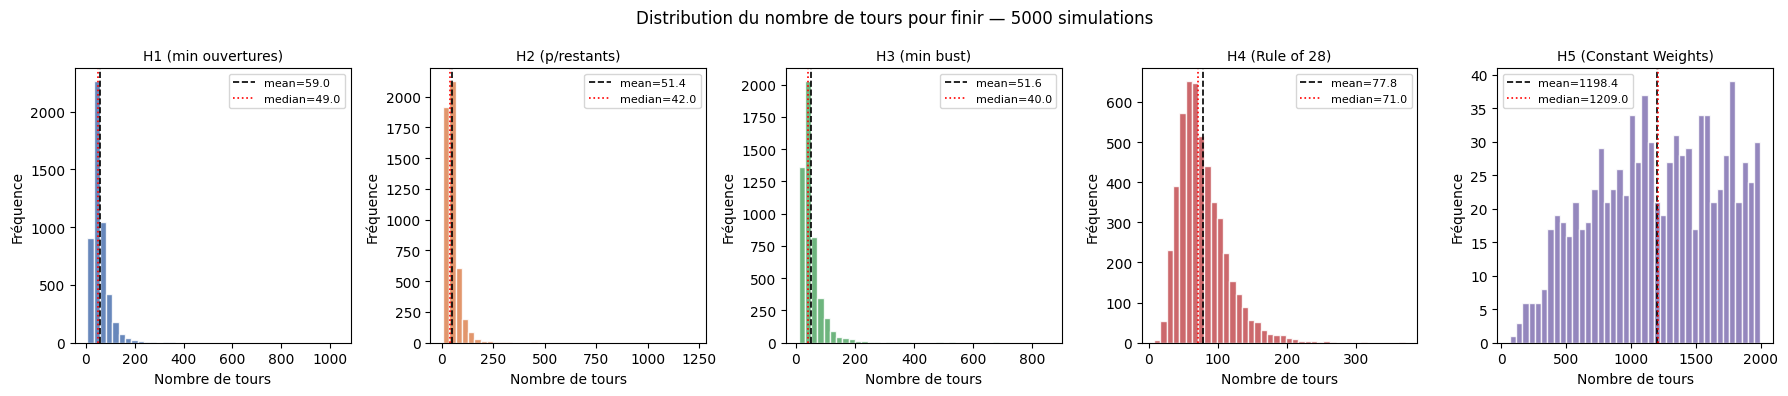

Figure sauvegardée : benchmark_heuristics.png


In [15]:
# ============================================================
# RÉSULTATS — histogrammes
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(results), figsize=(18, 4), sharey=False)

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

for ax, (name, s), color in zip(axes, results.items(), colors):
    ax.hist(s["scores"], bins=40, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(s["mean"], color="black", linestyle="--", linewidth=1.2, label=f"mean={s['mean']:.1f}")
    ax.axvline(s["median"], color="red", linestyle=":", linewidth=1.2, label=f"median={s['median']:.1f}")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Nombre de tours")
    ax.set_ylabel("Fréquence")
    ax.legend(fontsize=8)

plt.suptitle(f"Distribution du nombre de tours pour finir — {N_SIMULATIONS} simulations", fontsize=12)
plt.tight_layout()
plt.savefig("benchmark_heuristics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : benchmark_heuristics.png")